重新做一个非常粗糙的场下+场上 场下数据的模型对比 用RF

目的是为了证明off-court 会增加预测水准 R^2增高了很多 正在的场上baseline还是原来的74%

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 可选：XGBoost & LightGBM，不装的话会自动跳过
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

# 读 CSV（按你项目结构改一下路径）
DATA_PATH = Path("../data/processed/training_level1_full.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()




Shape: (2082, 132)


,player_id,season,salary_usd,log_salary,salary_cap,salary_cap_ratio,log_salary_cap_ratio,salary_cap_equiv,Age,GP,...,award_NBA Eastern Conference Finals MVP,award_NBA Western Conference Finals MVP,award_Rookie of the Year,award_Sixth Man of the Year,award_Twyman-Stokes Teammate of the Year Award,award_total,injury_events,injury_unique_dates,injury_unique_categories,injury_any
0,1,2020,43006362.0,17.576859,109140000.0,0.394048,0.332212,5.539837e+07,33,63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2020,28751775.0,17.174210,109140000.0,0.263439,0.233838,3.703642e+07,28,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,2020,31626953.0,17.269520,109140000.0,0.289783,0.254474,4.074006e+07,30,67,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,4,2020,29542010.0,17.201324,109140000.0,0.270680,0.239552,3.805435e+07,27,51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,2020,27528090.0,17.130718,109140000.0,0.252227,0.224924,3.546013e+07,26,61,...,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,1.0,True


In [11]:
# ID 列 & 目标列
ID_COLS = ["player_id", "season"]
TARGET_COL = "log_salary_cap_ratio"

assert TARGET_COL in df.columns, "log_salary_cap_ratio 不在 df 里，请检查 pipeline"

# 绝对不能进特征的“目标相关列”（泄露风险）
TARGET_LEAK_BASE = [
    "salary_usd",
    "log_salary",
    "salary_cap",
    "salary_cap_ratio",
    "log_salary_cap_ratio",
    "salary_cap_equiv",
]
# 除了真正的 TARGET 本身
TARGET_LEAK_COLS = [c for c in TARGET_LEAK_BASE if c != TARGET_COL]

# 纯文本 / ID 类列（不用来训练）
TEXT_OR_ID_COLS = [
    "Player",          # 如果有
    "player_name",     # 如果有
    "team_abbr",
    "city",
    "state",
    "region",
    "agent_name",
    "agent_name_all",
]

# 先得到“候选特征列”
candidate_feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [TARGET_COL] + TARGET_LEAK_COLS + TEXT_OR_ID_COLS
]

# 只保留数值 / bool 类型
numeric_bool_cols = df[candidate_feature_cols].select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("候选特征（数值+bool）个数:", len(numeric_bool_cols))
print("前 15 个:", numeric_bool_cols[:15])




候选特征（数值+bool）个数: 115
前 15 个: ['Age', 'GP', 'W', 'L', 'Min', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%']


In [12]:

# off-court 特征识别规则
OFFCOURT_PREFIXES = (
    "draft_",
    "award_",
    "injury_",
    "agent_",
    "team_",
)

OFFCOURT_CONTAINS = (
    "team",
    "market",
    "city",
    "state",
    "region",
    "pick",   # overall_pick / round_pick
)

OFFCOURT_EXACT = [
    "Age",
    "age_now",
    "years_since_draft",
    "overall_pick",
    "round",
    "round_pick",
    "draft_year",
    "undrafted_flag",
]

offcourt_cols = []
for c in numeric_bool_cols:
    lc = c.lower()
    if c.startswith(OFFCOURT_PREFIXES):
        offcourt_cols.append(c)
    elif any(key in lc for key in OFFCOURT_CONTAINS):
        offcourt_cols.append(c)
    elif c in OFFCOURT_EXACT:
        offcourt_cols.append(c)

offcourt_cols = sorted(list(set(offcourt_cols)))
oncourt_cols  = sorted(list(set(numeric_bool_cols) - set(offcourt_cols)))

print("On-court feature cols:", len(oncourt_cols))
print("Off-court feature cols:", len(offcourt_cols))

print("\nSample on-court cols:", oncourt_cols[:15])
print("\nSample off-court cols:", offcourt_cols[:15])



On-court feature cols: 81
Off-court feature cols: 34

Sample on-court cols: ['+/-', '3P%', '3PA', '3PA_per_gp', '3PA_per_min', '3PM', '3PM_per_gp', '3PM_per_min', 'AST', 'AST_TO_ratio', 'AST_per_gp', 'AST_per_min', 'BLK', 'BLK_per_gp', 'BLK_per_min']

Sample off-court cols: ['Age', 'age_now', 'agent_client_count', 'agent_is_top', 'award_All-Defensive', 'award_All-NBA', 'award_All-Rookie', 'award_All-Star MVP', 'award_Clutch Player of the Year', 'award_Coach of the Year', 'award_Defensive Player of the Year', 'award_Finals MVP', 'award_Most Improved Player', 'award_Most Valuable Player', 'award_NBA Cup All-Tournament Team']


In [13]:
print("Seasons:", sorted(df["season"].unique()))

# 2020–2023 作为训练，2024 作为测试
train_df = df[df["season"] < 2024].copy()
test_df  = df[df["season"] == 2024].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# 填缺失
train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

y_train = train_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

# Level0: on-court only
X_train_0 = train_df[oncourt_cols].values
X_test_0  = test_df[oncourt_cols].values

# Level1: on + off
feature_cols_1 = oncourt_cols + offcourt_cols
X_train_1 = train_df[feature_cols_1].values
X_test_1  = test_df[feature_cols_1].values


Seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train shape: (1659, 132)
Test shape : (423, 132)


In [14]:
def evaluate_regression(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)       # 不用 squared=False，兼容旧版本 sklearn
    r2 = r2_score(y_true, y_pred)
    # MAPE 会很大，仅作参考
    mape = np.mean(np.abs((y_true - y_pred) / y_true))

    print(f"=== {name} ===")
    print(f"MAE  : {mae:,.4f}")
    print(f"RMSE : {rmse:,.4f}")
    print(f"R^2  : {r2:.4f}")
    print(f"MAPE : {mape*100:.2f}%")
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}



In [15]:
def run_models_for_level(level_name, X_train, X_test, y_train, y_test):
    results = []

    
    # 1) Ridge：加 StandardScaler，正则稍微大一点
    ridge = make_pipeline(
        StandardScaler(),
        Ridge(alpha=10.0, random_state=42)
    )
    ridge.fit(X_train, y_train)
    y_tr = ridge.predict(X_train)
    y_te = ridge.predict(X_test)
    metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-Ridge-Train")
    metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-Ridge-Test")
    results.append({"level": level_name, "model": "Ridge", "split": "train", **metrics_tr})
    results.append({"level": level_name, "model": "Ridge", "split": "test",  **metrics_te})

    print("\n" + "-"*60 + "\n")

    # 2) RandomForest
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    y_tr = rf.predict(X_train)
    y_te = rf.predict(X_test)
    metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-RF-Train")
    metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-RF-Test")
    results.append({
        "level": level_name,
        "model": "RandomForest",
        "split": "train", **metrics_tr,
    })
    results.append({
        "level": level_name,
        "model": "RandomForest",
        "split": "test", **metrics_te,
    })

    print("\n" + "-"*60 + "\n")

    # 3) XGBoost（如果装了）
    if XGBRegressor is not None:
        xgb = XGBRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        )
        xgb.fit(X_train, y_train)
        y_tr = xgb.predict(X_train)
        y_te = xgb.predict(X_test)
        metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-XGB-Train")
        metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-XGB-Test")
        results.append({
            "level": level_name,
            "model": "XGB",
            "split": "train", **metrics_tr,
        })
        results.append({
            "level": level_name,
            "model": "XGB",
            "split": "test", **metrics_te,
        })

        print("\n" + "-"*60 + "\n")
    else:
        print(f"⚠ XGBoost not installed, skipping for {level_name}")

    # 4) LightGBM（如果装了）
    if LGBMRegressor is not None:
        lgbm = LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="regression",
            random_state=42,
            n_jobs=-1,
        )
        lgbm.fit(X_train, y_train)
        y_tr = lgbm.predict(X_train)
        y_te = lgbm.predict(X_test)
        metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-LGBM-Train")
        metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-LGBM-Test")
        results.append({
            "level": level_name,
            "model": "LGBM",
            "split": "train", **metrics_tr,
        })
        results.append({
            "level": level_name,
            "model": "LGBM",
            "split": "test", **metrics_te,
        })
    else:
        print(f"⚠ LightGBM not installed, skipping for {level_name}")

    return results




In [17]:
all_results = []

print("====== Level0: on-court only ======")
res0 = run_models_for_level("Level0_oncourt", X_train_0, X_test_0, y_train, y_test)
all_results.extend(res0)

print("\n\n====== Level1: on + off-court ======")
res1 = run_models_for_level("Level1_on_off", X_train_1, X_test_1, y_train, y_test)
all_results.extend(res1)

results_df = pd.DataFrame(all_results)
results_df


====== Level0: on-court only ======
=== Level0_oncourt-Ridge-Train ===
MAE  : 0.0335
RMSE : 0.0463
R^2  : 0.6281
MAPE : 265.81%
=== Level0_oncourt-Ridge-Test ===
MAE  : 0.0377
RMSE : 0.0520
R^2  : 0.5695
MAPE : 117.82%

------------------------------------------------------------

=== Level0_oncourt-RF-Train ===
MAE  : 0.0122
RMSE : 0.0173
R^2  : 0.9479
MAPE : 88.66%
=== Level0_oncourt-RF-Test ===
MAE  : 0.0367
RMSE : 0.0503
R^2  : 0.5972
MAPE : 116.95%

------------------------------------------------------------

=== Level0_oncourt-XGB-Train ===
MAE  : 0.0008
RMSE : 0.0011
R^2  : 0.9998
MAPE : 8.18%
=== Level0_oncourt-XGB-Test ===
MAE  : 0.0368
RMSE : 0.0511
R^2  : 0.5838
MAPE : 109.23%

------------------------------------------------------------

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14267
[LightGBM] [Info] Number of data points in

c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Level0_oncourt-LGBM-Train ===
MAE  : 0.0015
RMSE : 0.0022
R^2  : 0.9992
MAPE : 12.55%
=== Level0_oncourt-LGBM-Test ===
MAE  : 0.0361
RMSE : 0.0509
R^2  : 0.5875
MAPE : 108.91%


====== Level1: on + off-court ======
=== Level1_on_off-Ridge-Train ===
MAE  : 0.0293
RMSE : 0.0397
R^2  : 0.7268
MAPE : 217.94%
=== Level1_on_off-Ridge-Test ===
MAE  : 0.0339
RMSE : 0.0454
R^2  : 0.6719
MAPE : 120.62%

------------------------------------------------------------

=== Level1_on_off-RF-Train ===
MAE  : 0.0074
RMSE : 0.0116
R^2  : 0.9767
MAPE : 60.68%
=== Level1_on_off-RF-Test ===
MAE  : 0.0218
RMSE : 0.0330
R^2  : 0.8268
MAPE : 72.62%

------------------------------------------------------------

=== Level1_on_off-XGB-Train ===
MAE  : 0.0005
RMSE : 0.0006
R^2  : 0.9999
MAPE : 4.72%
=== Level1_on_off-XGB-Test ===
MAE  : 0.0222
RMSE : 0.0322
R^2  : 0.8349
MAPE : 73.35%

------------------------------------------------------------

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ov

c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,level,model,split,mae,rmse,r2,mape
0,Level0_oncourt,Ridge,train,0.033498,0.046318,0.628144,2.658103
1,Level0_oncourt,Ridge,test,0.037656,0.052016,0.569537,1.178228
2,Level0_oncourt,RandomForest,train,0.012238,0.017332,0.947932,0.886589
3,Level0_oncourt,RandomForest,test,0.036727,0.050314,0.597242,1.169466
4,Level0_oncourt,XGB,train,0.000813,0.001106,0.999788,0.081819
5,Level0_oncourt,XGB,test,0.036844,0.051147,0.583797,1.092320
6,Level0_oncourt,LGBM,train,0.001549,0.002153,0.999196,0.125491
7,Level0_oncourt,LGBM,test,0.036117,0.050921,0.587470,1.089124
8,Level1_on_off,Ridge,train,0.029290,0.039704,0.726756,2.179396
9,Level1_on_off,Ridge,test,0.033901,0.045410,0.671940,1.206215


In [8]:
# Level1: on-court + off-court 全部
feature_cols_1 = oncourt_cols + offcourt_cols

X_train_1 = train_df[feature_cols_1].values
X_test_1  = test_df[feature_cols_1].values

rf1 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)

rf1.fit(X_train_1, y_train)

y_pred_train_1 = rf1.predict(X_train_1)
y_pred_test_1  = rf1.predict(X_test_1)

print("Train performance (Level1 / on+off)")
metrics_train_1 = evaluate_regression(y_train, y_pred_train_1, name="Level1-Train")

print("\nTest performance (Level1 / on+off)")
metrics_test_1 = evaluate_regression(y_test, y_pred_test_1, name="Level1-Test")


Train performance (Level1 / on+off)
=== Level1-Train ===
MAE  : 0.0074
RMSE : 0.0116
R^2  : 0.9767
MAPE : 60.68%

Test performance (Level1 / on+off)
=== Level1-Test ===
MAE  : 0.0218
RMSE : 0.0330
R^2  : 0.8268
MAPE : 72.62%


In [9]:
# 结果对比
results = pd.DataFrame([
    {"model": "Level0_oncourt",  **metrics_test_0},
    {"model": "Level1_on_off",   **metrics_test_1},
])
results


NameError: name 'metrics_test_0' is not defined

In [ ]:
improvement = metrics_test_0["mae"] - metrics_test_1["mae"]
rel_imp = improvement / metrics_test_0["mae"] * 100

print(f"MAE improvement (Level1 vs Level0): {improvement:.4f}")
print(f"Relative improvement: {rel_imp:.2f}%")


MAE improvement (Level1 vs Level0): 0.0149
Relative improvement: 40.62%


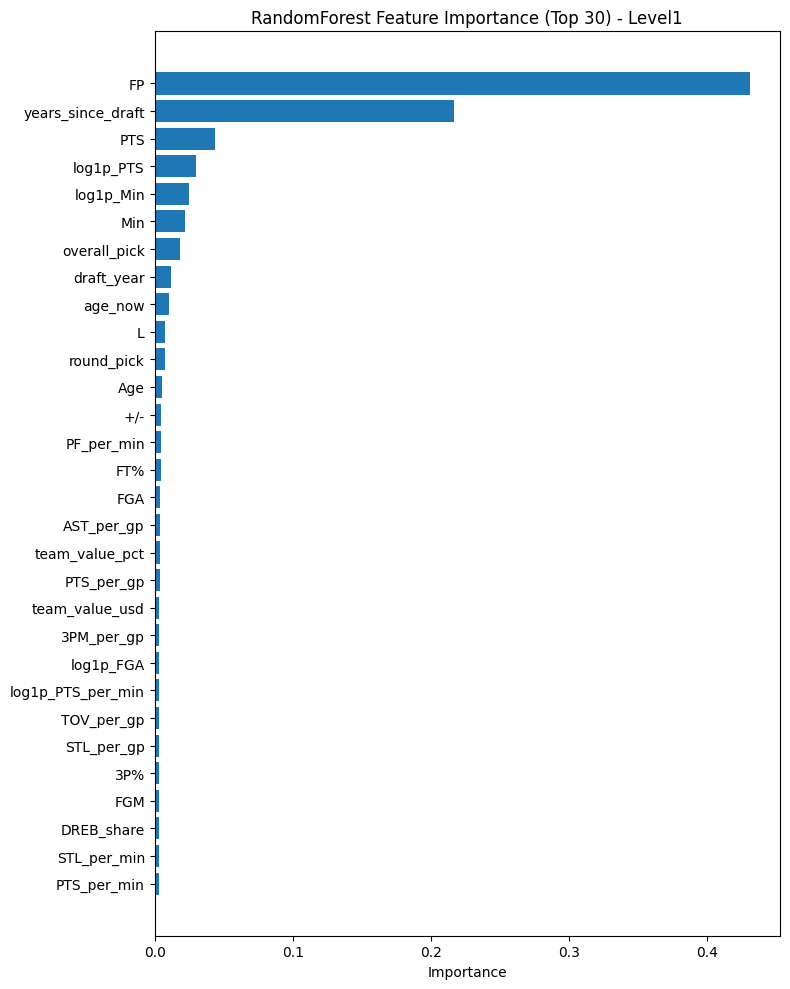

Off-court features in top-30: 8 / 30


,feature,importance,is_offcourt
47,PTS_per_min,0.002940,False
53,STL_per_min,0.002969,False
19,DREB_share,0.002995,False
24,FGM,0.002998,False
1,3P%,0.003017,False
52,STL_per_gp,0.003018,False
56,TOV_per_gp,0.003024,False
75,log1p_PTS_per_min,0.003084,False
67,log1p_FGA,0.003217,False
6,3PM_per_gp,0.003319,False


In [ ]:
#  看level1 特征重要性
importances = rf1.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_cols_1,
    "importance": importances,
})

feat_imp["is_offcourt"] = feat_imp["feature"].isin(offcourt_cols)
feat_imp = feat_imp.sort_values("importance", ascending=False)

top_k = 30
top = feat_imp.head(top_k).sort_values("importance")

plt.figure(figsize=(8, 10))
plt.barh(top["feature"], top["importance"])
plt.title(f"RandomForest Feature Importance (Top {top_k}) - Level1")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Off-court features in top-30:", top["is_offcourt"].sum(), "/", top_k)
top.head(10)
